In [1]:
"""
Test the response of the autaptic neuron to overloading step currents.

Is the autapse response still significant? Or do adaptation currents dull the effect?

"""

'\nTest the response of the autaptic neuron to overloading step currents.\n\nIs the autapse response still significant? Or do adaptation currents dull the effect?\n\n'

In [ ]:

import aqua

from aqua.batchAQUA_general import batchAQUA
from aqua.utils import *
from aqua.stimulus import *

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve, windows

In [3]:
RS = {'name': 'RS_ref', 'C': 100, 'k': 0.7, 'v_r': -60, 'v_t': -40, 'v_peak': 35,
     'a': 0.03, 'b': -2, 'c': -50, 'd': 100, 'e': 0., 'f': 0., 'tau': 0.}

RS_aut = {'name': 'RS_ref', 'C': 100, 'k': 0.7, 'v_r': -60, 'v_t': -40, 'v_peak': 35,
     'a': 0.03, 'b': -2, 'c': -50, 'd': 100, 'e': 0.2, 'f': 250., 'tau': 2.}


100%|██████████| 49999/49999 [00:07<00:00, 6612.19it/s]


Text(0.5, 0, 'Time [ms]')

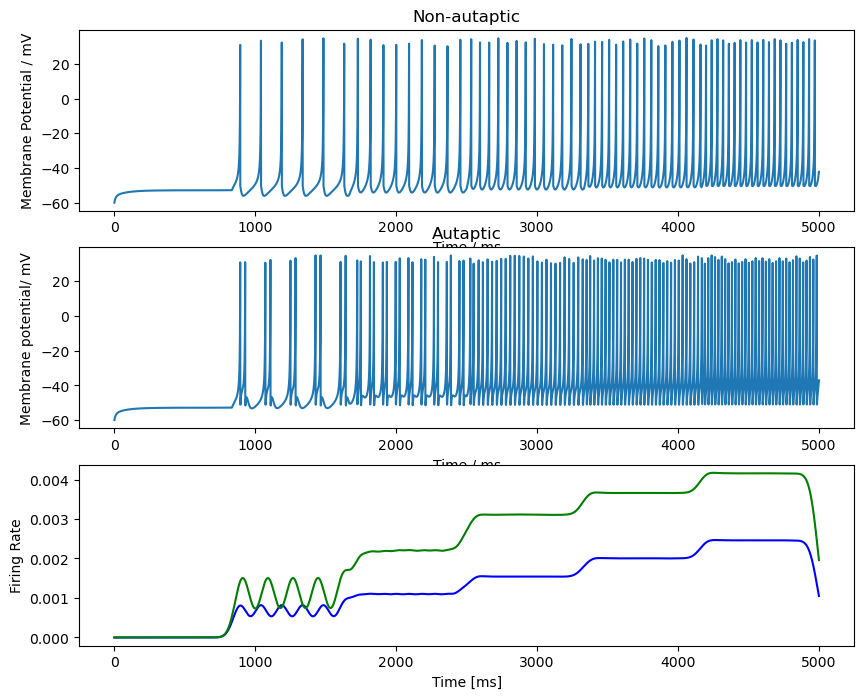

In [ ]:
# Base autapse parameters

T = 5000 # ms
dt = 0.1
N_iter = int(T/dt)

# injected current, staircase current
I_hs = np.arange(50, 151, 20)
I_inj = np.ones((2, N_iter))
I_segment = N_iter//len(I_hs)
for n, i in enumerate(I_hs):
    I_inj[:, n*I_segment:(n+1)*I_segment] = i*np.ones((2, I_segment))


# initial cond.
x_ini = np.array([-60, 0, 0])
x_start = np.full((2, 3), fill_value = x_ini)
t_ini = np.array([0., 0.])

# create neuron
batch = batchAQUA([RS, RS_aut])
batch.Initialise(x_start, t_ini)

# simulate
X, time, spikes = batch.update_batch(dt, N_iter, I_inj)

# plot output
fig, ax = plt.subplots(3, 1, figsize = (10, 8))

ax[0].plot(time, X[0, 0, :], label = "non-autaptic")
#ax[0].plot(time, X[1, 0, :], label = "test")
ax[0].set_xlabel("Time / ms")
ax[0].set_ylabel("Membrane Potential / mV")
ax[0].set_title("Non-autaptic")

ax[1].plot(time, X[1, 0, :], label = "autaptic")
ax[1].set_xlabel("Time / ms")
ax[1].set_ylabel("Membrane potential/ mV")
ax[1].set_title("Autaptic")

"""
ax[2].plot(time, I_inj[0, :], label = "I_inj")
ax[2].set_xlabel("Time / ms")
ax[2].set_ylabel("Injected Current / pA")
plt.legend()
"""

spike_raster = aqua.utils.binarise_spikes(spikes, dt, N_iter)
# gaussian filter
gauss = windows.gaussian(M = 10000, std = 500)
gauss /= gauss.sum()
gauss_2d = gauss[np.newaxis, :]

smooth_rate = convolve(spike_raster, gauss_2d, mode = 'same')

ax[2].plot(time, smooth_rate[0, :], c = 'blue')
ax[2].plot(time, smooth_rate[1, :], c = 'green')
ax[2].set_ylabel("Firing Rate")
ax[2].set_xlabel("Time [ms]")
#plt.legend()

(2, 50000)


Text(0.5, 0, 'Time [ms]')

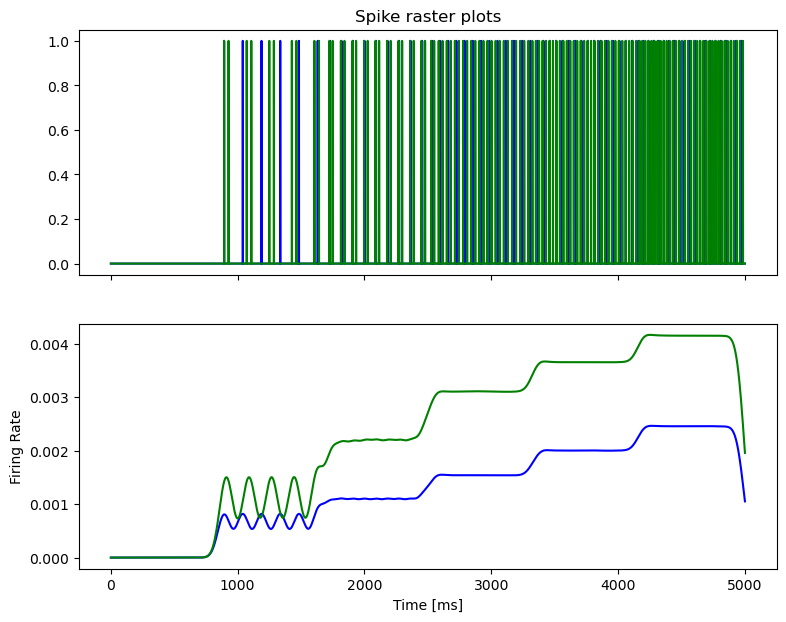

In [7]:
from scipy.signal import convolve, windows

spike_raster = aqua.utils.binarise_spikes(spikes, dt, N_iter)
# gaussian filter
gauss = windows.gaussian(M = 10000, std = 500)
gauss /= gauss.sum()
gauss_2d = gauss[np.newaxis, :]

smooth_rate = convolve(spike_raster, gauss_2d, mode = 'same')
print(np.shape(smooth_rate))
fig, ax = plt.subplots(2, 1, figsize = (9, 7), sharex = True)

ax[0].plot(time, spike_raster[0, :], c = 'blue', label = 'non-autaptic')
ax[0].plot(time, spike_raster[1, :], c = 'green', label = 'autaptic')
ax[0].set_title("Spike raster plots")


ax[1].plot(time, smooth_rate[0, :], c = 'blue')
ax[1].plot(time, smooth_rate[1, :], c = 'green')
ax[1].set_ylabel("Firing Rate")
ax[1].set_xlabel("Time [ms]")


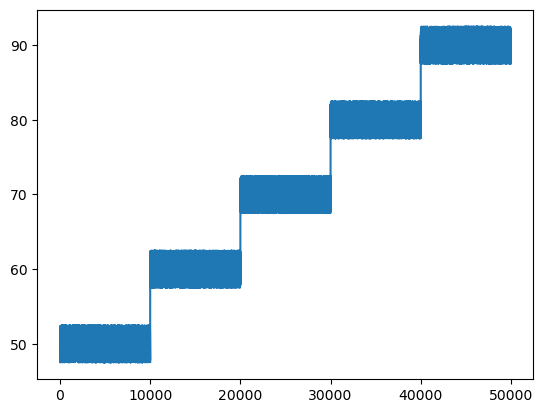

100%|██████████| 49999/49999 [00:11<00:00, 4493.87it/s]


Text(0.5, 0, 'Time [ms]')

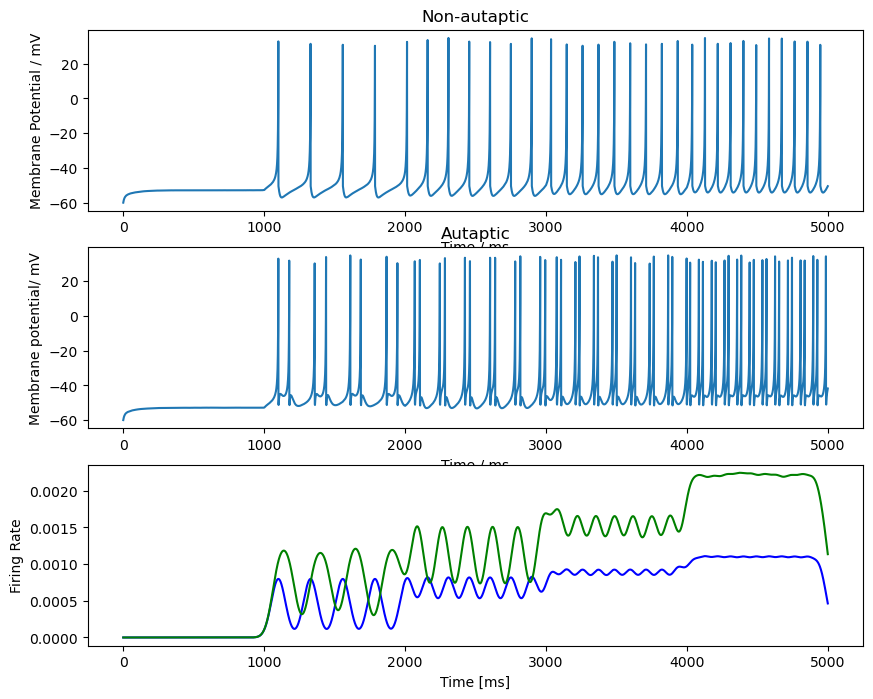

In [18]:
# Base autapse parameters

T = 5000 # ms
dt = 0.1
N_iter = int(T/dt)

# injected current, staircase current
I_hs = np.arange(50, 91, 10)
I_noise = 5
I_inj = np.ones((2, N_iter))
I_segment = N_iter//len(I_hs)
for n, i in enumerate(I_hs):
    I_inj[:, n*I_segment:(n+1)*I_segment] = i*np.ones((2, I_segment)) + I_noise*(np.random.random_sample((2, I_segment))-0.5)

plt.plot(I_inj[0, :])
plt.show()

# initial cond.
x_ini = np.array([-60, 0, 0])
x_start = np.full((2, 3), fill_value = x_ini)
t_ini = np.array([0., 0.])

# create neuron
batch = batchAQUA([RS, RS_aut])
batch.Initialise(x_start, t_ini)

# simulate
X, time, spikes = batch.update_batch(dt, N_iter, I_inj)

# plot output
fig, ax = plt.subplots(3, 1, figsize = (10, 8))

ax[0].plot(time, X[0, 0, :], label = "non-autaptic")
#ax[0].plot(time, X[1, 0, :], label = "test")
ax[0].set_xlabel("Time / ms")
ax[0].set_ylabel("Membrane Potential / mV")
ax[0].set_title("Non-autaptic")

ax[1].plot(time, X[1, 0, :], label = "autaptic")
ax[1].set_xlabel("Time / ms")
ax[1].set_ylabel("Membrane potential/ mV")
ax[1].set_title("Autaptic")

"""
ax[2].plot(time, I_inj[0, :], label = "I_inj")
ax[2].set_xlabel("Time / ms")
ax[2].set_ylabel("Injected Current / pA")
plt.legend()
"""

spike_raster = aqua.utils.binarise_spikes(spikes, dt, N_iter)
# gaussian filter
gauss = windows.gaussian(M = 10000, std = 500)
gauss /= gauss.sum()
gauss_2d = gauss[np.newaxis, :]

smooth_rate = convolve(spike_raster, gauss_2d, mode = 'same')

ax[2].plot(time, smooth_rate[0, :], c = 'blue')
ax[2].plot(time, smooth_rate[1, :], c = 'green')
ax[2].set_ylabel("Firing Rate")
ax[2].set_xlabel("Time [ms]")
#plt.legend()

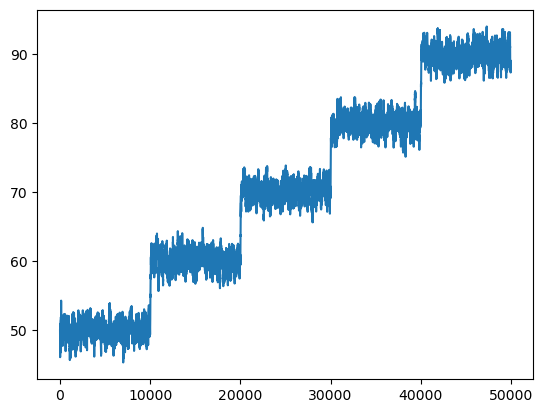

100%|██████████| 49999/49999 [00:11<00:00, 4363.14it/s]


Text(0.5, 0, 'Time [ms]')

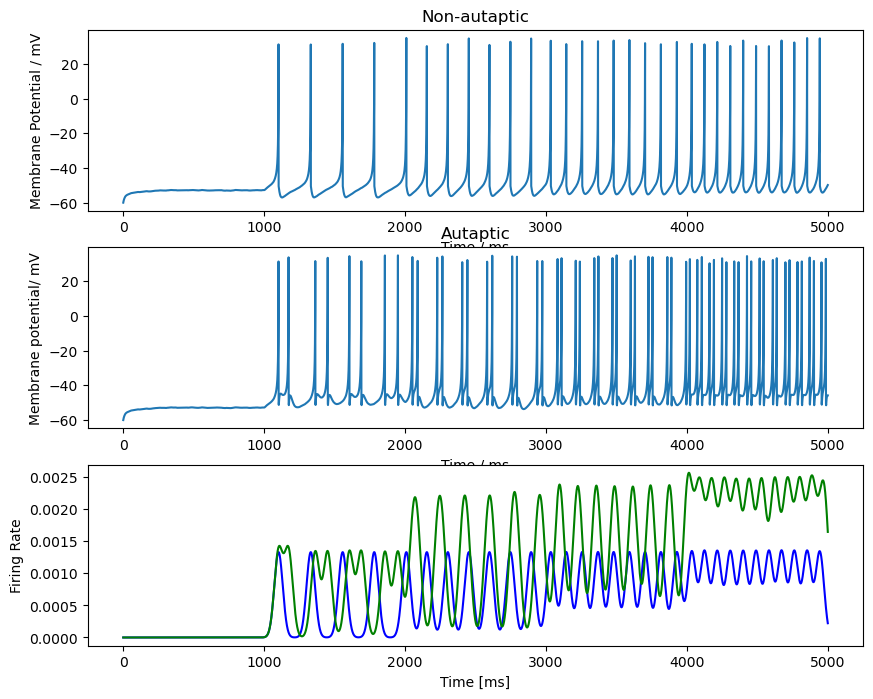

In [40]:
# Base autapse parameters

T = 5000 # ms
dt = 0.1
N_iter = int(T/dt)

# injected current, staircase current
I_hs = np.arange(50, 91, 10)
#I_noise = 5
theta = 0.3
sigma = 1.
I_mean = np.zeros((N_iter))
I_segment = N_iter//len(I_hs)
for n, i in enumerate(I_hs):
    I_mean[n*I_segment:(n+1)*I_segment] = i*np.ones((I_segment))

ou = OU_current(N_iter, dt, I_hs[0], theta = theta, mu = I_mean, sigma = sigma)
I_ou = np.array([ou, ou])
plt.plot(I_ou[0, :])
plt.show()

# initial cond.
x_ini = np.array([-60, 0, 0])
x_start = np.full((2, 3), fill_value = x_ini)
t_ini = np.array([0., 0.])

# create neuron
batch = batchAQUA([RS, RS_aut])
batch.Initialise(x_start, t_ini)

# simulate
X, time, spikes = batch.update_batch(dt, N_iter, I_ou)

# plot output
fig, ax = plt.subplots(3, 1, figsize = (10, 8))

ax[0].plot(time, X[0, 0, :], label = "non-autaptic")
#ax[0].plot(time, X[1, 0, :], label = "test")
ax[0].set_xlabel("Time / ms")
ax[0].set_ylabel("Membrane Potential / mV")
ax[0].set_title("Non-autaptic")

ax[1].plot(time, X[1, 0, :], label = "autaptic")
ax[1].set_xlabel("Time / ms")
ax[1].set_ylabel("Membrane potential/ mV")
ax[1].set_title("Autaptic")

"""
ax[2].plot(time, I_inj[0, :], label = "I_inj")
ax[2].set_xlabel("Time / ms")
ax[2].set_ylabel("Injected Current / pA")
plt.legend()
"""

spike_raster = aqua.utils.binarise_spikes(spikes, dt, N_iter)
# gaussian filter
gauss = windows.gaussian(M = 10000, std = 300)
gauss /= gauss.sum()
gauss_2d = gauss[np.newaxis, :]

smooth_rate = convolve(spike_raster, gauss_2d, mode = 'same')

ax[2].plot(time, smooth_rate[0, :], c = 'blue')
ax[2].plot(time, smooth_rate[1, :], c = 'green')
ax[2].set_ylabel("Firing Rate")
ax[2].set_xlabel("Time [ms]")
#plt.legend()

From Claudia's lecture:


"speeded decision making and attentional control"


Could the autapse also reduce the amount of evidence needed to estimate the height of the driving current? This might be related to the bursting dynamcis (i.e. estimating the height from the initial interburst interval)